# SGD's Frequency Bias and How Adam Fixes It
Modern language models are trained on data with extremely uneven token distributions. A small number of words appear in almost every sentence, while many rare but meaningful tokens occur only occasionally. This creates a hidden optimization challenge: parameters associated with common tokens receive constant gradient updates, while parameters tied to rare tokens may go hundreds or thousands of steps without receiving any meaningful signal. Under standard Stochastic Gradient Descent (SGD), every parameter uses the same learning rate, so frequently updated weights converge quickly while rare-token weights often remain close to their random initialization.

This is where Adam’s adaptive optimization becomes important. While Adam is commonly described as SGD with momentum, its most impactful feature in practice is variance normalization. Adam tracks the historical gradient statistics for each parameter independently and automatically adjusts update sizes based on how often reliable gradient information has been observed. Parameters that rarely receive updates end up getting proportionally larger effective learning rates, allowing underrepresented features to learn much faster than they would under vanilla SGD.

To demonstrate this behavior concretely, we build a controlled NumPy experiment using a six-token vocabulary spanning four orders of magnitude in frequency — from tokens appearing in nearly every batch to tokens appearing only 0.1% of the time. We train the same linear model twice, once with SGD and once with Adam, while keeping all target weights identical. By comparing final parameter values, non-zero gradient counts, and Adam’s effective learning rates for each token, we can directly observe how adaptive optimization compensates for frequency imbalance in real training dynamics.


## Setting up the dependencies
We begin by constructing a deliberately simplified training environment that isolates a single factor: token frequency. The vocabulary contains six tokens ranging from extremely common words like “the” to very rare tokens like “thalweg,” with appearance probabilities spanning four orders of magnitude. Every token is assigned the same ground-truth importance — the correct weight for all tokens is set to 1.0 — so the experiment removes semantic complexity and focuses entirely on how often each parameter receives gradient updates.

Each training sample is represented as a sparse binary vector indicating which tokens are present in the batch. The target value is simply the sum of the active token weights plus a small amount of noise. We then train a small linear model using this synthetic dataset. Because gradients are only computed for tokens that appear in a batch, rare tokens naturally receive far fewer updates than common ones. This setup creates a clean environment for observing how SGD and Adam behave under highly imbalanced gradient exposure.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

np.random.seed(42)

In [5]:
TOKENS = ["the", "model", "embedding", "tokenization", "xenobiotic", "thalweg"]
# Appearance probability per batch — spans 4 orders of magnitude
FREQ   = np.array([0.95,   0.60,    0.20,          0.05,          0.005,       0.001])
TRUE_W = np.ones(6)   # all weights should reach 1.0

N_STEPS   = 3000
LR        = 0.05
BATCH_SIZE = 32     # samples per step


def sample_batch(batch_size):
    """
    Each sample is a sparse binary feature vector.
    Token i appears in the sample with probability FREQ[i].
    Target y = x @ TRUE_W + small noise.
    """
    X = (np.random.rand(batch_size, 6) < FREQ).astype(float)
    y = X @ TRUE_W + np.random.randn(batch_size) * 0.1
    return X, y

## SGD
We first train the model using standard mini-batch SGD. The model weights are initialized to zero, and at every training step we sample a batch, compute the prediction error, calculate the average gradient across the batch, and update the weights using a fixed learning rate. The implementation also records the full weight trajectory over time along with the number of steps in which each parameter received a non-zero gradient.

The key behavior emerges from the sparsity of the input vectors. A token only contributes to the gradient when it appears in the sampled batch. For common tokens, this happens almost every step, so their associated weights receive frequent updates and converge quickly. Rare tokens, however, are absent from most batches, causing their gradients to remain near zero for long stretches of training. As a result, SGD spends most of its optimization effort on high-frequency tokens while low-frequency tokens barely move from initialization.

In [6]:
def train_sgd(n_steps, lr, batch_size):
    w        = np.zeros(6)
    history  = np.zeros((n_steps, 6))   # weight trajectory per token
    grad_counts = np.zeros(6)            # how many non-zero gradients each weight got

    for t in range(n_steps):
        X, y    = sample_batch(batch_size)
        error   = X @ w - y
        grad    = (X.T @ error) / batch_size
        w      -= lr * grad

        grad_counts += (np.abs(grad) > 1e-9).astype(float)
        history[t]  = w.copy()

    return history, grad_counts

## ADAM
We now train the same model using Adam to observe how adaptive optimization changes the learning dynamics. Alongside the model weights, Adam maintains two additional running statistics for every parameter: a momentum estimate mmm, which tracks the average direction of past gradients, and a variance estimate vvv, which tracks the average magnitude of squared gradients. Before applying updates, both statistics are bias-corrected to account for their initialization at zero.

In [7]:
def train_adam(n_steps, lr, batch_size, beta1=0.9, beta2=0.999, eps=1e-8):
    w        = np.zeros(6)
    m        = np.zeros(6)
    v        = np.zeros(6)
    history  = np.zeros((n_steps, 6))
    v_history = np.zeros((n_steps, 6))  # track variance accumulation

    for t in range(1, n_steps + 1):
        X, y   = sample_batch(batch_size)
        error  = X @ w - y
        grad   = (X.T @ error) / batch_size

        m = beta1 * m + (1 - beta1) * grad
        v = beta2 * v + (1 - beta2) * grad ** 2

        m_hat = m / (1 - beta1 ** t)
        v_hat = v / (1 - beta2 ** t)

        w -= lr * m_hat / (np.sqrt(v_hat) + eps)

        history[t-1]   = w.copy()
        v_history[t-1] = v_hat.copy()

    return history, v_history


## Running both
With both optimizers implemented, we train the model twice under identical conditions — once using SGD and once using Adam. Each optimizer sees the same synthetic data distribution, uses the same initialization, learning rate, batch size, and training duration. This ensures that any difference in the final behavior comes entirely from the optimization strategy itself rather than changes in the dataset or model architecture.

In [3]:
print("Training SGD...")
sgd_history, sgd_grad_counts = train_sgd(N_STEPS, LR, BATCH_SIZE)

print("Training Adam...")
adam_history, adam_v_history = train_adam(N_STEPS, LR, BATCH_SIZE)

print()

Training SGD...
Training Adam...



## Measuring the failure
We now evaluate how well each optimizer learned the token weights after training. Since every token has the same true target weight of 1.0, the ideal outcome is that all learned weights also end close to 1.0 regardless of token frequency. Along with the final weights, we also measure how many training steps each token actually received a non-zero gradient. This helps us directly compare optimization quality against gradient exposure frequency.

The results clearly show the difference between SGD and Adam. For common tokens, both optimizers learn the correct weights successfully because these tokens appear in almost every batch. But for rare tokens, SGD struggles badly. “xenobiotic” only receives gradients in about 15% of training steps and its weight stops around 0.53 instead of 1.0. The rarest token, “thalweg,” receives gradients in only 3.4% of steps and SGD barely learns it at all, ending near 0.15. Adam, however, keeps both rare-token weights close to the correct value despite receiving the same sparse gradient signals.

In [8]:
sgd_final  = sgd_history[-1]
adam_final = adam_history[-1]

print("=" * 62)
print(f"{'Token':<16} {'Freq':>6}  {'SGD w':>8}  {'Adam w':>8}  {'SGD grads':>10}")
print("-" * 62)
for i, token in enumerate(TOKENS):
    sgd_err  = abs(sgd_final[i]  - TRUE_W[i])
    adam_err = abs(adam_final[i] - TRUE_W[i])
    flag = "  ← fails" if sgd_err > 0.3 else ""
    print(
        f"{token:<16} {FREQ[i]:>6.3f}  {sgd_final[i]:>8.4f}  "
        f"{adam_final[i]:>8.4f}  {int(sgd_grad_counts[i]):>10}{flag}"
    )
print()
print(f"True weight for all tokens: {TRUE_W[0]:.1f}")
print()

# How many steps did each token get a non-zero gradient?
print("Non-zero gradient steps out of", N_STEPS)
for i, token in enumerate(TOKENS):
    pct = sgd_grad_counts[i] / N_STEPS * 100
    bar = "█" * int(pct / 2)
    print(f"  {token:<16} {bar:<50} {pct:.1f}%")

print()


Token              Freq     SGD w    Adam w   SGD grads
--------------------------------------------------------------
the               0.950    1.0056    0.9792        3000
model             0.600    0.9998    0.9699        3000
embedding         0.200    0.9989    1.0037        2996
tokenization      0.050    0.9976    1.0622        2407
xenobiotic        0.005    0.5348    1.0458         451  ← fails
thalweg           0.001    0.1470    1.0938         103  ← fails

True weight for all tokens: 1.0

Non-zero gradient steps out of 3000
  the              ██████████████████████████████████████████████████ 100.0%
  model            ██████████████████████████████████████████████████ 100.0%
  embedding        █████████████████████████████████████████████████  99.9%
  tokenization     ████████████████████████████████████████           80.2%
  xenobiotic       ███████                                            15.0%
  thalweg          █                                                  3.4%


## Effective Learning Rate
To understand why Adam succeeds on rare tokens, we examine its effective learning rate for each parameter at the end of training. Adam does not use the same update scale for every weight. Instead, each parameter’s update is divided by the square root of its accumulated variance estimate vvv. This means the practical step size depends on how large or small that variance has become during training.

The numbers reveal a clear pattern. Common tokens such as “the” and “model” accumulate large variance values because they receive gradients almost every step, so their effective learning rates remain relatively small. Rare tokens behave very differently. Since “xenobiotic” and “thalweg” receive gradients only occasionally, their variance estimates stay tiny, causing Adam to automatically amplify their effective learning rates by a massive amount. Even though the nominal learning rate is fixed at 0.05, the rarest token ends up receiving an effective step size above 40. This adaptive scaling is the core reason Adam can learn sparse parameters that SGD fails to optimize properly.

In [9]:
eps = 1e-8
adam_v_final    = adam_v_history[-1]
effective_lr    = LR / (np.sqrt(adam_v_final) + eps)

print("=" * 55)
print("Adam Effective Learning Rate (final step)")
print("=" * 55)
for i, token in enumerate(TOKENS):
    print(f"  {token:<16}  v_hat={adam_v_final[i]:.6f}  lr_eff={effective_lr[i]:.4f}")
print()
print(f"Nominal LR: {LR}")
print("Rare tokens get an automatically amplified effective LR.")
print()

Adam Effective Learning Rate (final step)
  the               v_hat=0.001800  lr_eff=1.1784
  model             v_hat=0.001089  lr_eff=1.5153
  embedding         v_hat=0.000241  lr_eff=3.2236
  tokenization      v_hat=0.000033  lr_eff=8.7126
  xenobiotic        v_hat=0.000003  lr_eff=30.6880
  thalweg           v_hat=0.000001  lr_eff=41.2451

Nominal LR: 0.05
Rare tokens get an automatically amplified effective LR.



## Visualizing the Results
Finally, we visualize the full training dynamics to compare how SGD and Adam behave across tokens with vastly different frequencies. The first two plots track the weight trajectories during training, showing whether each optimizer can move rare-token parameters toward the correct value. We also compare the final weight errors for every token to measure overall learning quality.

The four charts tell a single story across two optimizers. The top-left shows SGD's weight trajectories: common tokens (dark and medium blue) shoot up to 1.0 within the first few hundred steps, while the two rare tokens — xenobiotic and thalweg — barely leave the floor, crawling to 0.53 and 0.15 respectively after all 3,000 steps. The top-right bar chart makes the damage concrete: SGD's error bars for xenobiotic and thalweg dwarf everything else, while Adam's blue bars stay uniformly small across all six tokens.

The bottom-left shows Adam's trajectories — all six tokens converge to 1.0, including the rare ones, though with more oscillation because each rare gradient update carries a large amplified step. The bottom-right explains why: plotted on a log-log scale, the relationship between token frequency and Adam's effective learning rate is a clean inverse — thalweg sits at the top-left with a 41× amplified effective LR, "the" sits at the bottom-right near the nominal 0.05, and every other token falls on the same diagonal. Adam did not receive any special instructions about which tokens were rare; the variance term computed it automatically from gradient history alone.

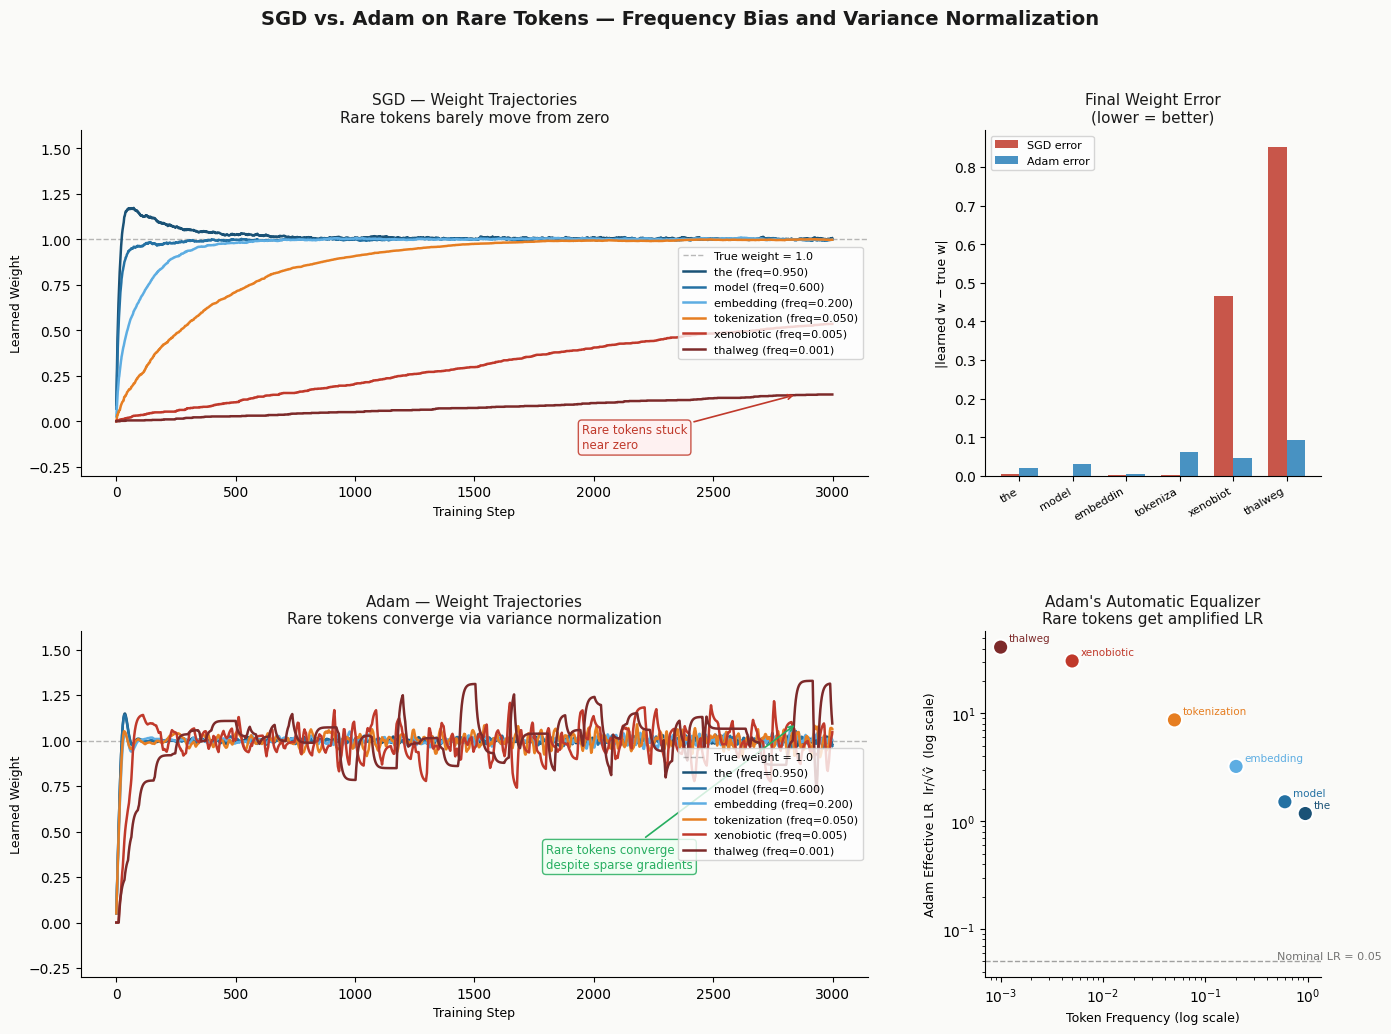

In [10]:
BG   = "#fafaf8"
DARK = "#1a1a1a"

# Color ramp: blue for common tokens, red for rare
TOKEN_COLORS = ["#1a5276", "#2471a3", "#5dade2", "#e67e22", "#c0392b", "#7d2a2a"]

steps = np.arange(N_STEPS)

fig = plt.figure(figsize=(16, 11), facecolor=BG)
fig.suptitle(
    "SGD vs. Adam on Rare Tokens — Frequency Bias and Variance Normalization",
    fontsize=14, fontweight="bold", color=DARK, y=0.99
)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── 1. SGD weight trajectories ────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
ax1.set_facecolor(BG)
ax1.axhline(1.0, color=DARK, lw=1, ls="--", alpha=0.3, label="True weight = 1.0")

for i, (token, color) in enumerate(zip(TOKENS, TOKEN_COLORS)):
    ax1.plot(steps, sgd_history[:, i], color=color, lw=1.8,
             label=f"{token} (freq={FREQ[i]:.3f})")

ax1.set_title("SGD — Weight Trajectories\nRare tokens barely move from zero", fontsize=11, color=DARK)
ax1.set_xlabel("Training Step", fontsize=9)
ax1.set_ylabel("Learned Weight", fontsize=9)
ax1.legend(fontsize=8, loc="right")
ax1.set_ylim(-0.3, 1.6)
ax1.spines[["top", "right"]].set_visible(False)

# Annotate failure zone
ax1.annotate(
    "Rare tokens stuck\nnear zero",
    xy=(N_STEPS * 0.95, sgd_history[-1, 5]),
    xytext=(N_STEPS * 0.65, -0.15),
    fontsize=8.5, color="#c0392b",
    arrowprops=dict(arrowstyle="->", color="#c0392b", lw=1.2),
    bbox=dict(boxstyle="round,pad=0.3", facecolor="#fff0f0", edgecolor="#c0392b", alpha=0.85)
)

# ── 2. Final weight error bar chart ───────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
ax2.set_facecolor(BG)

x      = np.arange(6)
w_sgd  = sgd_final
w_adam = adam_final
width  = 0.35

bars_sgd  = ax2.bar(x - width/2, np.abs(w_sgd  - TRUE_W), width, color="#c0392b", alpha=0.85, label="SGD error")
bars_adam = ax2.bar(x + width/2, np.abs(w_adam - TRUE_W), width, color="#2980b9", alpha=0.85, label="Adam error")

ax2.set_xticks(x)
ax2.set_xticklabels([t[:8] for t in TOKENS], rotation=30, ha="right", fontsize=8)
ax2.set_ylabel("|learned w − true w|", fontsize=9)
ax2.set_title("Final Weight Error\n(lower = better)", fontsize=11, color=DARK)
ax2.legend(fontsize=8)
ax2.spines[["top", "right"]].set_visible(False)

# ── 3. Adam weight trajectories ───────────────────────────────
ax3 = fig.add_subplot(gs[1, :2])
ax3.set_facecolor(BG)
ax3.axhline(1.0, color=DARK, lw=1, ls="--", alpha=0.3, label="True weight = 1.0")

for i, (token, color) in enumerate(zip(TOKENS, TOKEN_COLORS)):
    ax3.plot(steps, adam_history[:, i], color=color, lw=1.8,
             label=f"{token} (freq={FREQ[i]:.3f})")

ax3.set_title("Adam — Weight Trajectories\nRare tokens converge via variance normalization", fontsize=11, color=DARK)
ax3.set_xlabel("Training Step", fontsize=9)
ax3.set_ylabel("Learned Weight", fontsize=9)
ax3.legend(fontsize=8, loc="right")
ax3.set_ylim(-0.3, 1.6)
ax3.spines[["top", "right"]].set_visible(False)

ax3.annotate(
    "Rare tokens converge\ndespite sparse gradients",
    xy=(N_STEPS * 0.95, adam_history[-1, 5]),
    xytext=(N_STEPS * 0.60, 0.3),
    fontsize=8.5, color="#27ae60",
    arrowprops=dict(arrowstyle="->", color="#27ae60", lw=1.2),
    bbox=dict(boxstyle="round,pad=0.3", facecolor="#f0fff4", edgecolor="#27ae60", alpha=0.85)
)

# ── 4. Effective LR vs frequency ─────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
ax4.set_facecolor(BG)

ax4.scatter(FREQ, effective_lr, c=TOKEN_COLORS, s=120, zorder=5, edgecolors="white", lw=1.5)
for i, token in enumerate(TOKENS):
    ax4.annotate(token, (FREQ[i], effective_lr[i]),
                 textcoords="offset points", xytext=(6, 4), fontsize=7.5, color=TOKEN_COLORS[i])

ax4.axhline(LR, color=DARK, lw=1, ls="--", alpha=0.4)
ax4.text(0.5, LR * 1.05, f"Nominal LR = {LR}", fontsize=8, color=DARK, alpha=0.6)

ax4.set_xscale("log")
ax4.set_yscale("log")
ax4.set_xlabel("Token Frequency (log scale)", fontsize=9)
ax4.set_ylabel("Adam Effective LR  lr/√v̂  (log scale)", fontsize=9)
ax4.set_title("Adam's Automatic Equalizer\nRare tokens get amplified LR", fontsize=11, color=DARK)
ax4.spines[["top", "right"]].set_visible(False)

plt.savefig("sgd_vs_adam.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()